# NumPy Day 1: The Foundation of Numerical Computing

## Week 5, Day 1 - From Visualization to the Engine Room

---

### Today's Journey (2.5 Hours)

| Part | Topic | Duration |
|------|-------|----------|
| 1 | Why NumPy? From Visualization to the Engine Room | ~20 min |
| 2 | Creating Arrays: Your First Building Blocks | ~30 min |
| | **BREAK 1** | 10 min |
| 3 | Indexing, Slicing & Reshaping | ~30 min |
| 4 | Array Operations & Aggregations | ~20 min |
| | **BREAK 2** | 10 min |
| 5 | Random Numbers & Simulations | ~20 min |
| 6 | Boolean Indexing & Filtering | ~20 min |
| 7 | Mini-Project: Weather Analysis Challenge | ~30 min |

---

```
TODAY'S PROMISE:

    ┌─────────────────────────────────────────────────────────────────────┐
    │                                                                     │
    │   Last weeks, you mastered the TOOLS:                              │
    │   - Pandas for data manipulation                                   │
    │   - Matplotlib and Seaborn for visualization                      │
    │   - Preprocessing pipelines for cleaning data                     │
    │                                                                     │
    │   This week, you discover the ENGINE:                             │
    │   - NumPy: the library that POWERS pandas, matplotlib,            │
    │     scikit-learn, TensorFlow, and every major data tool           │
    │                                                                     │
    │   By the end of today:                                            │
    │   - You'll create and manipulate arrays with confidence           │
    │   - You'll understand WHY NumPy is 100x faster than Python        │
    │   - You'll generate synthetic data and filter it like a pro       │
    │   - You'll build a weather analysis from scratch                  │
    │                                                                     │
    │   Everything you learned so far sits ON TOP of NumPy.             │
    │   Today you meet the foundation.                                  │
    │                                                                     │
    └─────────────────────────────────────────────────────────────────────┘
```

## Setup - Run This First

In [31]:
# All imports for today's lecture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')

print(f"NumPy version: {np.__version__}")
print("All libraries loaded! Ready for NumPy.")

NumPy version: 2.0.2
All libraries loaded! Ready for NumPy.


---

# Part 1: Why NumPy? From Visualization to the Engine Room

## What Powers Everything You've Learned

---

```
THE DATA SCIENCE STACK - What You've Been Using:

    ┌─────────────────────────────────────────────────────────┐
    │              YOUR TOOLS (what you see)                   │
    │                                                         │
    │   Pandas          Matplotlib        Seaborn             │
    │   DataFrames      Plots             Statistical Viz     │
    │   .groupby()      .plot()           .histplot()         │
    │   .merge()        .scatter()        .boxplot()          │
    └─────────────────────┬───────────────────────────────────┘
                          │
                          │  ALL built on top of...
                          │
    ┌─────────────────────▼───────────────────────────────────┐
    │                                                         │
    │                    N U M P Y                            │
    │                                                         │
    │              The Engine Room                            │
    │                                                         │
    │   - ndarray: the core data structure                    │
    │   - Vectorized operations (no loops needed)             │
    │   - 10-100x faster than Python lists                    │
    │   - Powers ALL scientific Python                        │
    │                                                         │
    └─────────────────────────────────────────────────────────┘
```

In [32]:
# === LIVE CODING: What's hiding inside a pandas DataFrame? ===
# Create a DataFrame and use .values to see the NumPy array underneath
df = pd.DataFrame({
    'temperature': [23, 25, 22, 28, 26],
    'humidity': [65, 70, 60, 75, 68],
    'city': ['NYC', 'LA', 'Chicago', 'Miami', 'Seattle']
})

print(f"Pandas Dataframe:")
print(df)
print() # prints an empty line

temperatures = df['temperature'].values

print(f"Type of df['temperature']: {type(df['temperature'])}")
print(f"Type of df['temperature'].values: {type(temperatures)}")
print(f"The NumPy array underneath: {temperatures}")
print()


Pandas Dataframe:
   temperature  humidity     city
0           23        65      NYC
1           25        70       LA
2           22        60  Chicago
3           28        75    Miami
4           26        68  Seattle

Type of df['temperature']: <class 'pandas.core.series.Series'>
Type of df['temperature'].values: <class 'numpy.ndarray'>
The NumPy array underneath: [23 25 22 28 26]



In [33]:
# === LIVE CODING: Speed comparison - Python list vs NumPy ===
# Double 1 million numbers with a list comprehension vs NumPy
size = 1_000_000

python_list = list(range(size))
numpy_array = np.arange(size)

# Time Python list
start = time.time()
result_list = [x * 2 for x in python_list]
python_time = time.time() - start

# Time NumPy array
start = time.time()
result_numpy = numpy_array * 2 # uses Vectorization
numpy_time = time.time() - start

print(f"Doubling {size:,} numbers:")
print(f"   Python list: {python_time:.4f} seconds")
print(f"   NumPy array: {numpy_time:.4f} seconds")
print(f"   NumPy is {python_time/numpy_time:.0f}x faster")

# C, Vectorization

Doubling 1,000,000 numbers:
   Python list: 0.9913 seconds
   NumPy array: 0.0692 seconds
   NumPy is 14x faster


```
WHY IS NUMPY SO FAST?

    PYTHON LIST (slow):
    ┌───┐  ┌───┐  ┌───┐  ┌───┐  ┌───┐
    │ 1 │→ │ 2 │→ │ 3 │→ │ 4 │→ │ 5 │   Each number stored separately
    └───┘  └───┘  └───┘  └───┘  └───┘   Process one at a time (loop)
      ↓      ↓      ↓      ↓      ↓
     ×2     ×2     ×2     ×2     ×2      5 separate operations


    NUMPY ARRAY (fast):
    ┌───┬───┬───┬───┬───┐
    │ 1 │ 2 │ 3 │ 4 │ 5 │                Stored in one continuous block
    └───┴───┴───┴───┴───┘                Process ALL at once (vectorized)
              ↓
           × 2 (one operation on entire block)
              ↓
    ┌───┬───┬───┬───┬───┐
    │ 2 │ 4 │ 6 │ 8 │10 │
    └───┴───┴───┴───┴───┘


    KEY DIFFERENCES:
    ┌──────────────────────┬──────────────────────┐
    │    Python List       │    NumPy Array        │
    ├──────────────────────┼──────────────────────┤
    │ Mixed types allowed  │ All same type         │
    │ Scattered in memory  │ Contiguous memory     │
    │ Needs Python loops   │ Vectorized (C code)   │
    │ Flexible             │ Fast                  │
    └──────────────────────┴──────────────────────┘
```

---

# Part 2: Creating Arrays - Your First Building Blocks

## Seven Ways to Create NumPy Arrays

---

```
UNDERSTANDING DIMENSIONS:

    0D (Scalar):  Just a number
    ┌───┐
    │ 7 │         shape: ()     ndim: 0
    └───┘

    1D (Vector):  A row of values
    ┌───┬───┬───┬───┬───┐
    │ 1 │ 2 │ 3 │ 4 │ 5 │     shape: (5,)    ndim: 1
    └───┴───┴───┴───┴───┘

    2D (Matrix):  Rows and columns (like a DataFrame!)
    ┌───┬───┬───┬───┐
    │ 1 │ 2 │ 3 │ 4 │
    ├───┼───┼───┼───┤     shape: (3, 4)   ndim: 2
    │ 5 │ 6 │ 7 │ 8 │
    ├───┼───┼───┼───┤
    │ 9 │10 │11 │12 │
    └───┴───┴───┴───┘

    KEY INSIGHT:
    - pandas Series  = labeled 1D NumPy array
    - pandas DataFrame = labeled 2D NumPy array
```

In [34]:
# === LIVE CODING: Explore 0D, 1D, 2D arrays ===
# Check .ndim and .shape for each
scalar = np.array(7)
print(f"Scalar: value={scalar}, ndim={scalar.ndim}, shape={scalar.shape}")

vector = np.array([1, 2, 3, 4, 5])
print(f"Vector: value={vector}, ndim={vector.ndim}, shape={vector.shape}")

matrix = np.array([[1, 2, 3, 0], [4, 5, 6, 0], [9, 10, 11, 0]])
print(f"Matrix: value={matrix}, ndim={matrix.ndim}, shape={matrix.shape}")


Scalar: value=7, ndim=0, shape=()
Vector: value=[1 2 3 4 5], ndim=1, shape=(5,)
Matrix: value=[[ 1  2  3  0]
 [ 4  5  6  0]
 [ 9 10 11  0]], ndim=2, shape=(3, 4)


```
ARRAY CREATION METHODS - Your Toolkit:

    ┌──────────────────────────────────────────────────────────────────┐
    │ METHOD          │ WHAT IT DOES                │ EXAMPLE          │
    ├─────────────────┼─────────────────────────────┼──────────────────┤
    │ np.array()      │ Convert list to array        │ np.array([1,2]) │
    │ np.arange()     │ Range with step size         │ np.arange(0,10) │
    │ np.zeros()      │ Array of zeros               │ np.zeros(5)     │
    │ np.ones()       │ Array of ones                │ np.ones((3,3))  │
    │ np.eye()        │ Identity matrix              │ np.eye(4)       │
    │ np.linspace()   │ Evenly spaced (exact count)  │ np.linspace(0,1,50) │
    │ np.random.*     │ Random numbers               │ (Part 5)        │
    └─────────────────┴─────────────────────────────┴──────────────────┘
```

## Method 1: np.array() - Convert a List

In [35]:
# === LIVE CODING: Create 1D and 2D arrays from lists ===
array = np.array([10, 20, 30, 40, 50])
print(f"1D array: {array}")
print(f"Type: {type(array)}")
print(f"Shape: {array.shape}")
print(f"Dtype: {array.dtype}")

1D array: [10 20 30 40 50]
Type: <class 'numpy.ndarray'>
Shape: (5,)
Dtype: int64


In [36]:
matrix = np.array([
                  [1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]
                ])

print("2D array(matrix): ")
print(matrix)
print(f"Shape: {matrix.shape}")
print(f"Dtype: {matrix.dtype}")

2D array(matrix): 
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)
Dtype: int64


## Practice: Exercise 1

**Create a 1D NumPy array containing the numbers 0 through 9.**

Hint: You can pass a Python list or use `np.arange()`.

Expected output: `array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])`

**Time: 2 minutes**

In [37]:
# Your code here for Exercise 1
# np.array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

array = np.arange(10) # automatically creates an array of numbers from 0 to 10
print(array)

[0 1 2 3 4 5 6 7 8 9]


## Data Types (dtype) - Every Element Must Match

In [38]:
# === LIVE CODING: Explore dtypes and type conversion ===
# Try: np.array([1, 2, 3]) vs np.array([1.5, 2.7, 3.14])
# Try: .astype(int) and .astype(float)
integer_array = np.array([1, 2, 3])
print(f"Integer array: {integer_array}, dtype: {integer_array.dtype}")

float_array = np.array([1.5, 2.7, 3.14])
print(f"Float array: {float_array}, dtype: {float_array.dtype}")

mixed = np.array([1, 2, 3.14])
print(f"Mixed input: {mixed}, dtype: {mixed.dtype}")  #convierte los int a float

Integer array: [1 2 3], dtype: int64
Float array: [1.5  2.7  3.14], dtype: float64
Mixed input: [1.   2.   3.14], dtype: float64


In [39]:
numbers_array = np.array([1,2,3])
print(numbers_array)

floats_array = numbers_array.astype('float')
print(floats_array)

[1 2 3]
[1. 2. 3.]


In [40]:
booleans = np.array([True, True, False])
print(booleans)

booleans_binary = booleans.astype(int)
print(booleans_binary)

[ True  True False]
[1 1 0]


In [41]:
str_array = np.array(['abba', 123])  #convierte el int a str porque necesita que sean todos del mismo dtype
print(str_array)

['abba' '123']


## Practice: Exercise 2

**Convert a Python list of floats `[1.5, 2.7, 3.9, 4.1, 5.8]` into a NumPy array of integers.**

Hint: Create the array with `np.array()`, then use `.astype(int)`.

Note: `.astype(int)` truncates (cuts off decimals), it does NOT round.

Expected output: `array([1, 2, 3, 4, 5])`

**Time: 2 minutes**

In [42]:
# Your code here for Exercise 2
float_list = [1.5, 2.7, 3.9, 4.1, 5.8]
numpy_float_array = np.array(float_list)
numpy_integer_array = numpy_float_array.astype('int8')

print(numpy_integer_array)
print(f"Dtype: {numpy_integer_array.dtype}")

[1 2 3 4 5]
Dtype: int8


## Method 2: np.arange() - Range with Step Size

In [43]:
# === LIVE CODING: Create arrays with arange ===
# Try: np.arange(10), np.arange(1, 11), np.arange(0, 21, 2)
print(f"0-9: {np.arange(10)}")
print(f"1-10(included): {np.arange(1, 11)}")
print(f"0 to 20 by 2: {np.arange(0, 21, 2)}")
print(f"10 to 1(desc): {np.arange(10, 0, -1)}")

0-9: [0 1 2 3 4 5 6 7 8 9]
1-10(included): [ 1  2  3  4  5  6  7  8  9 10]
0 to 20 by 2: [ 0  2  4  6  8 10 12 14 16 18 20]
10 to 1(desc): [10  9  8  7  6  5  4  3  2  1]


## Practice: Exercise 3

**Create a 3x3 NumPy array containing the values 1 through 9.**

Hint: Use `np.array()` with a list of three lists: `[[1,2,3], [4,5,6], [7,8,9]]`.

Expected output:
```
array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])
```

**Time: 2 minutes**

In [44]:
# Your code here for Exercise 3
# matrix = np.array([[1,2,3], [4,5,6], [7,8,9]])
# print(matrix)

np.arange(1, 10).reshape(3, 3) # 9, 3x3  #reshape

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

## Method 3: np.zeros() and np.ones() - Pre-filled Arrays

```
WHY ZEROS AND ONES?

    np.zeros() - "Give me an empty structure to fill later"
    ─────────────────────────────────────────────────────
    Gradebook:     np.zeros((30, 5))   → 30 students, 5 assignments
    Image canvas:  np.zeros((100, 100)) → blank 100x100 image
    Accumulator:   np.zeros(12)        → monthly totals, start at 0

    np.ones() - "Give me a structure with default value 1"
    ─────────────────────────────────────────────────────
    Weights:       np.ones(5) / 5      → equal weights (0.2 each)
    Selection:     np.ones(100)        → include everything
    Ratings:       np.ones((users, items)) → default rating of 1
```

In [45]:
# === LIVE CODING: Create arrays with zeros and ones ===
# Try: np.zeros(5), np.zeros((3, 4)), np.ones((2, 3))
print("1D zeros:", np.zeros(5))
print()

print("2D zeros (3x4):")
print(np.zeros((3,4))) # not np.zeros(3,4)   --> es una tupla, por eso va el doble paréntesis
print()

print("1D ones:", np.ones(5))
print()

print("2D ones(2x3):")
print(np.ones((2,3)))     #  es una tupla, por eso va el doble paréntesis

1D zeros: [0. 0. 0. 0. 0.]

2D zeros (3x4):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

1D ones: [1. 1. 1. 1. 1.]

2D ones(2x3):
[[1. 1. 1.]
 [1. 1. 1.]]


## Method 4: np.eye() - Identity Matrix

In [46]:
# === LIVE CODING: Create identity matrices ===
# Try: np.eye(3), np.eye(4)
print("3x3 Identity:")
print(np.eye(3))
print()

print("4x4 identity:")
print(np.eye(4))
print()

# Why? It's like multiplying by 1 - no change
A = np.array([[5, 10], [15, 20]])
result = A @ np.eye(2) # Matrix multiplication with identity
print(A)
print("\nA @ Identity = A (unchanged)")
print(result.astype(int))

3x3 Identity:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

4x4 identity:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

[[ 5 10]
 [15 20]]

A @ Identity = A (unchanged)
[[ 5 10]
 [15 20]]


## Practice: Exercise 4

**Create a 4x4 identity matrix using `np.eye()`.**

Expected output:
```
array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])
```

**Time: 1 minute**

In [47]:
# Your code here for Exercise 4
identity = np.eye(4)
print(identity)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


## Method 5: np.linspace() - Exact Number of Points

```
arange vs linspace - WHEN TO USE WHICH:

    ┌─────────────────────────────────────────────────────────────────┐
    │                                                                 │
    │   "I want numbers from 0 to 10 stepping by 2"                  │
    │   → np.arange(0, 11, 2)    # You know the STEP SIZE           │
    │                                                                 │
    │   "I want exactly 50 points between 0 and 10"                  │
    │   → np.linspace(0, 10, 50)  # You know the COUNT              │
    │                                                                 │
    ├─────────────────────────────────────────────────────────────────┤
    │                                                                 │
    │   RULE OF THUMB:                                               │
    │   - Integers + known step  → arange                            │
    │   - Exact count needed     → linspace                          │
    │   - Plotting smooth curves → linspace (always)                 │
    │   - Floats                 → linspace (safer)                  │
    │                                                                 │
    └─────────────────────────────────────────────────────────────────┘
```

In [48]:
# === LIVE CODING: linspace for smooth plots ===
# Try: np.linspace(0, 10, 5) and np.linspace(0, 2*np.pi, 200) for sine wave
array = np.linspace(0, 10, 5)
print(f"5 points from 0 to 10: {array}")

array = np.linspace(0, 1, 11)
print(f"11 points from 0 to 1: {array}")

5 points from 0 to 10: [ 0.   2.5  5.   7.5 10. ]
11 points from 0 to 1: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


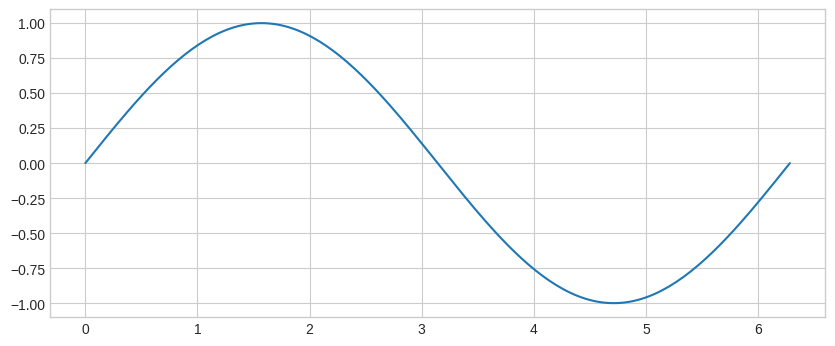

In [49]:
# Sine wave

x = np.linspace(0, 2 * np.pi, 200) # 200 points = smooth
y = np.sin(x)

plt.figure(figsize=(10, 4))
plt.plot(x, y)

## Array Attributes - Know Your Array

In [50]:
# === LIVE CODING: Check shape, ndim, size, dtype ===

matrix = np.arange(1, 13).reshape(3, 4)
print("Matrix")
print(matrix)
print()

print(f"Shape: {matrix.shape}") # (rows, columns)
print(f"ndim: {matrix.ndim}") # numbers of dimensions
print(f"size: {matrix.size}") # total elements
print(f"dtype: {matrix.dtype}") # data type

Matrix
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Shape: (3, 4)
ndim: 2
size: 12
dtype: int64


---

## BREAK 1 (10 Minutes)

### What we've covered:
- NumPy is the engine under pandas, matplotlib, and every data tool
- Dimensions: 0D (scalar), 1D (vector), 2D (matrix)
- Creating arrays: `np.array()`, `np.arange()`, `np.zeros()`, `np.ones()`, `np.eye()`, `np.linspace()`
- Array attributes: shape, ndim, size, dtype
- Type conversion with `.astype()`

### Coming up after break:
- **Indexing & Slicing** - Selecting exactly the data you need
- **Reshaping** - Changing array dimensions

---

---

# Part 3: Indexing, Slicing & Reshaping

## Selecting and Rearranging Data

---

## 1D Indexing and Slicing

In [51]:
# === LIVE CODING: 1D indexing and slicing ===
# arr = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])
# Try: arr[0], arr[-1], arr[:3], arr[::2], arr[::-1], arra[2:5]

arr = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])

print(f"1st Element [0]: {arr[0]}")
print(f"3rd Element [2]: {arr[2]}")
print(f"Last Element [-1]: {arr[-1]}")
print()

# Slicing
print(f"First 3 [:3]: {arr[:3]}")
print(f"Last 3 [-3:]: {arr[-3:]}")
print(f"Middle [3:6]: {arr[3:6]}")
print(f"Every other [::2]: {arr[::2]}")
print(f"Reversed [::-1]: {arr[::-1]}")

1st Element [0]: 10
3rd Element [2]: 30
Last Element [-1]: 90

First 3 [:3]: [10 20 30]
Last 3 [-3:]: [70 80 90]
Middle [3:6]: [40 50 60]
Every other [::2]: [10 30 50 70 90]
Reversed [::-1]: [90 80 70 60 50 40 30 20 10]


## Practice: Exercise 5

**Given the array `[10, 20, 30, 40, 50]`, reverse it using slicing.**

Hint: Use `[::-1]`.

Expected output: `array([50, 40, 30, 20, 10])`

**Time: 1 minute**

In [52]:
# Your code here for Exercise 5
array = np.array([10, 20, 30, 40, 50])
reversed_array = array[::-1]
print(reversed_array)

[50 40 30 20 10]


## 2D Indexing

```
2D ARRAY INDEXING - The Address System:

    matrix[row, col]

              col 0  col 1  col 2  col 3
            ┌──────┬──────┬──────┬──────┐
    row 0   │  10  │  11  │  12  │  13  │
            ├──────┼──────┼──────┼──────┤
    row 1   │  14  │  15  │  16  │  17  │  ← matrix[1] = entire row
            ├──────┼──────┼──────┼──────┤
    row 2   │  18  │  19  │  20  │  21  │
            └──────┴──────┴──────┴──────┘
                           ↑
                   matrix[:, 2] = entire column

    matrix[1, 3] = 17   (row 1, column 3)
    matrix[0]    = [10, 11, 12, 13]   (entire row 0)
    matrix[:, 2] = [12, 16, 20]       (entire column 2)
```

In [53]:
# === LIVE CODING: 2D indexing ===
# matrix = np.array([[10,11,12,13],[14,15,16,17],[18,19,20,21]])
# Try: matrix[0,0], matrix[1,3], matrix[1], matrix[:,2]
matrix = np.array([[10,11,12,13],
                   [14,15,16,17],
                   [18,19,20,21]])

print("Matrix:")
print(matrix)
print()

# Single element
print(f"matrix[0,0] = {matrix[0, 0]} (top-left)")
print(f"matrix[1, 3] = {matrix[1, 3]} (row 1, column 3)")
print()

# Entire row
print(f"matrix[1] = {matrix[1]} (second row)")   #df.loc[1,:]
print()

# Entire column
print(f"matrix[:, 2] = {matrix[:, 2]} (thrid column)")    #df.loc[:,3]

Matrix:
[[10 11 12 13]
 [14 15 16 17]
 [18 19 20 21]]

matrix[0,0] = 10 (top-left)
matrix[1, 3] = 17 (row 1, column 3)

matrix[1] = [14 15 16 17] (second row)

matrix[:, 2] = [12 16 20] (thrid column)


## Practice: Exercise 6

**Create a 2D array with values 1-12 shaped as 3 rows and 4 columns. Then select the second row.**

Hint: Use `np.array()` with three lists: `[[1,2,3,4], [5,6,7,8], [9,10,11,12]]`. Then index with `[1]` for the second row.

Expected output for the array:
```
array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])
```
Expected output for second row: `array([5, 6, 7, 8])`

**Time: 2 minutes**

In [54]:
# Your code here for Exercise 6
matrix = np.arange(1, 13).reshape(3, 4)
print("Matrix:")
print(matrix)
print()
print(f"Second row: {matrix[1]}")

Matrix:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Second row: [5 6 7 8]


## Reshaping Arrays

```
RESHAPE RULE: Total elements must match!

    20 elements:
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

    reshape(4, 5) = 4×5 = 20 elements    ← Works!
    reshape(5, 4) = 5×4 = 20 elements    ← Works!
    reshape(2, 10) = 2×10 = 20 elements  ← Works!
    reshape(3, 7) = 3×7 = 21 elements    ← ERROR! (21 ≠ 20)
```

In [55]:
# === LIVE CODING: Reshaping arrays ===
# arr = np.arange(1, 21)
# Try: arr.reshape(4, 5), arr.reshape(5, 4)
arr = np.arange(1, 21)
print(f"1D array: {arr}")
print(f"Shape: {arr.shape}")

# Reshape to 4x5
matrix = arr.reshape(4, 5)
print("Reshaped to 4x5:")
print(matrix)
print(f"Shape: {matrix.shape}")

print()

# Reshape to 5x4
matrix2 = arr.reshape(5, 4)
print("Reshaped to 5x4:")
print(f"Shape: {matrix2.shape}")

print(matrix2)

1D array: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Shape: (20,)
Reshaped to 4x5:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]]
Shape: (4, 5)

Reshaped to 5x4:
Shape: (5, 4)
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]
 [17 18 19 20]]


## Practice: Exercise 7

**Create a 1D array with values 1 through 20, then reshape it into a 4x5 matrix.**

Expected output:
```
array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20]])
```

**Time: 2 minutes**

In [56]:
# Your code here for Exercise 7
array = np.arange(1, 21) # 20 element
matrix = array.reshape(4, 5)
print(matrix)

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]]


---

# Part 4: Array Operations & Aggregations

## Math on Entire Arrays at Once

---

```
VECTORIZED OPERATIONS - No Loops Needed:

    Python list:                    NumPy array:
    ──────────                      ──────────
    [x + 10 for x in my_list]      my_array + 10
    [x * 2 for x in my_list]       my_array * 2
    [x ** 2 for x in my_list]      my_array ** 2
    sum(my_list)                    my_array.sum()
    statistics.mean(my_list)        my_array.mean()

    SAME RESULTS, but NumPy is 50-100x faster!
```

In [57]:
# === LIVE CODING: Element-wise operations ===
# arr = np.array([1, 2, 3, 4, 5])
# Try: arr + 10, arr * 3, arr ** 2
array = np.array([1, 2, 3, 4, 5])
print(f"Original: {array}")
print(f"Add 10: {array + 10}")
print(f"Multiply by 3: {array * 3}")
print(f"Squared: {array ** 2}")
print(f"Square root: {np.sqrt(array)}")

Original: [1 2 3 4 5]
Add 10: [11 12 13 14 15]
Multiply by 3: [ 3  6  9 12 15]
Squared: [ 1  4  9 16 25]
Square root: [1.         1.41421356 1.73205081 2.         2.23606798]


In [58]:
# === LIVE CODING: Operations between two arrays ===
# a = np.array([10, 20, 30])
# b = np.array([1, 2, 3])
# Try: a + b, a * b, a / b
a = np.array([10, 20, 30])
b = np.array([1, 2, 3])

print(f"a: {a}")
print(f"b: {b}")
print(f"a + b: {a + b}")
print(f"a * b: {a * b}")
print(f"a / b: {a / b}")

a: [10 20 30]
b: [1 2 3]
a + b: [11 22 33]
a * b: [10 40 90]
a / b: [10. 10. 10.]


## Aggregations - Summary Statistics

In [59]:
# === LIVE CODING: Aggregations ===
# Try: .sum(), .mean(), .min(), .max(), .std()
array = np.array([15, 23, 8, 42, 16, 4 ,47, 29, 11, 33])
print(f"Array: {array}")
print()

print(f"Sum: {array.sum()}")
print(f"Mean: {array.mean()}")
print(f"Min: {array.min()}")
print(f"Max: {array.max()}")
print(f"Std dev: {array.std():.2f}")

Array: [15 23  8 42 16  4 47 29 11 33]

Sum: 228
Mean: 22.8
Min: 4
Max: 47
Std dev: 13.84


## Finding Positions: .argmin() and .argmax()

In [60]:
# === LIVE CODING: .argmin() and .argmax() ===
# .min()/.max() = the value, .argmin()/.argmax() = the position

scores = np.array([78, 92, 65, 88, 95, 71, 83, 90])
students = ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank', 'Grace', 'Hank']

print(f"Scores: {scores}")
print(f"Highest Score: {scores.max()} (position ({scores.argmax()}))")
print(f"That's {students[scores.argmax()]}!")

print()


print(f"Loest Score: {scores.min()} (position ({scores.argmin()}))")
print(f"That's {students[scores.argmin()]}!")

Scores: [78 92 65 88 95 71 83 90]
Highest Score: 95 (position (4))
That's Eve!

Loest Score: 65 (position (2))
That's Carol!


## Practice: Exercise 8

**Create a 1D array with at least 5 numbers. Calculate the sum AND the average.**

Use `.sum()` and `.mean()`.

**Time: 2 minutes**

In [ ]:
# Your code here for Exercise 8
array = np.array([10, 20, 30, 40, 50])
print(f"Array: {array}")
print(f"Sum: {array.sum()}")
print(f"Average: {array.mean()}")

Array: [10 20 30 40 50]
Sum: 150
Average: 30.0


```
UNDERSTANDING AXIS:

         axis=1 →→→
       ┌───┬───┬───┐
    a  │ 1 │ 2 │ 3 │ →  sum = 6   (row sum)
    x  ├───┼───┼───┤
    i  │ 4 │ 5 │ 6 │ →  sum = 15
    s  ├───┼───┼───┤
    =  │ 7 │ 8 │ 9 │ →  sum = 24
    0  └───┴───┴───┘
    ↓    ↓   ↓   ↓
    ↓   12  15  18     (column sums)

    axis=0: collapse ROWS    → result per column
    axis=1: collapse COLUMNS → result per row
```

In [ ]:
# === LIVE CODING: Axis operations on 2D arrays ===
# matrix = np.array([[1,2,3],[4,5,6],[7,8,9]])
# Try: matrix.sum(), matrix.sum(axis=0), matrix.sum(axis=1)
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

print("Matrix:")
print(matrix)
print()

print(f"Total sum: {matrix.sum()}")
print(f"Sum per column (axis=0): {matrix.sum(axis=0)}")
print(f"Sum per row (axis=1): {matrix.sum(axis=1)}")
print()
print(f"Average per column (axis=0): {matrix.mean(axis=0)}")
print(f"Average per row (axis=1): {matrix.mean(axis=1)}")

Matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Total sum: 45
Sum per column (axis=0): [12 15 18]
Sum per row (axis=1): [ 6 15 24]

Average per column (axis=0): [4. 5. 6.]
Average per row (axis=1): [2. 5. 8.]


---

## BREAK 2 (10 Minutes)

### What we've covered:
- 1D and 2D indexing and slicing
- Reshaping arrays (same data, different layout)
- Vectorized operations (no loops!)
- Aggregations: sum, mean, min, max, std
- Finding positions with argmin/argmax
- Axis operations for row/column calculations

### Coming up after break:
- **Random Numbers** - Generating synthetic data
- **Boolean Indexing** - Filtering arrays with conditions
- **Weather Analysis Challenge** - Putting it all together

---

---

# Part 5: Random Numbers & Simulations

## Generating Synthetic Data

---

```
RANDOM NUMBER METHODS:

    ┌────────────────────────┬────────────────────────────────────────┐
    │ METHOD                 │ WHAT IT GENERATES                      │
    ├────────────────────────┼────────────────────────────────────────┤
    │ np.random.random()     │ Floats in [0, 1)                      │
    │ np.random.uniform(a,b) │ Floats in [a, b)                      │
    │ np.random.randint(a,b) │ Integers in [a, b)                    │
    │ np.random.seed(n)      │ Set seed for reproducibility          │
    └────────────────────────┴────────────────────────────────────────┘
```

In [62]:
# === LIVE CODING: Random number generation ===
# Try: np.random.random(5), np.random.uniform(-5, 35, 5), np.random.randint(1, 7, 10)

np.random.seed(42) # this preserves the random number set (can be recreated in the future)

# Random floats between 0 and 1
print(f"random(): floats in [0, 1]")
print(np.random.random(5))
print()

# Random floats in a range
print("uniform(-5, 35): floats in [-5, 35]")
print(np.random.uniform(-5, 35, 5))
print()

#Random integers
print("randint(1, 7): integers in [1, 7] = dice rolls")
print(np.random.randint(1, 7, 10))

random(): floats in [0, 1]
[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]

uniform(-5, 35): floats in [-5, 35]
[ 1.23978081 -2.67665551 29.64704583 19.04460047 23.32290311]

randint(1, 7): integers in [1, 7] = dice rolls
[6 5 2 4 6 6 2 4 5 1]


## Practice: Exercise 9

**Create a 2D array of shape (4, 5) filled with random numbers between 0 and 1.**

Hint: Use `np.random.random((4, 5))`.

**Time: 2 minutes**

In [ ]:
# Your code here for Exercise 9
np.random.seed(42)
random_array = np.random.random((4, 5))
print(random_array)

[[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
 [0.15599452 0.05808361 0.86617615 0.60111501 0.70807258]
 [0.02058449 0.96990985 0.83244264 0.21233911 0.18182497]
 [0.18340451 0.30424224 0.52475643 0.43194502 0.29122914]]


In [ ]:
# === LIVE CODING: Seeds and reproducibility ===
# np.random.seed(42) then generate random numbers twice
np.random.seed(42)

In [ ]:
# === LIVE CODING: 2D random arrays ===
# np.random.randint(0, 100, (3, 4))
np.random.seed(42)

random_matrix = np.random.randint(0, 100, (3,4))
print(random_matrix)
print()

city_temps = np.random.uniform(-5, 35, (10, 12))
print(f"City temperatures shape: {city_temps.shape}")
print(f"First city, first 6 months:", city_temps[0, :6])

[[51 92 14 71]
 [60 20 82 86]
 [74 74 87 99]]

City temperatures shape: (10, 12)
First city, first 6 months: [ 0.71467272 21.03553892 -2.74353684 23.87995089 32.54210836 -4.96884937]


---

# Part 6: Boolean Indexing & Filtering

## Filtering Arrays with Conditions

---

```
BOOLEAN INDEXING - How It Works:

    arr = [3, 7, 1, 9, 4, 6, 2, 8]

    Step 1: Create a mask
    arr > 5  →  [F, T, F, T, F, T, F, T]

    Step 2: Apply the mask
    arr[arr > 5]  →  [7, 9, 6, 8]

    Only elements where mask is True are kept!

    COMBINING CONDITIONS:
    ─────────────────────
    AND: (arr > 3) & (arr < 8)   → elements between 3 and 8
    OR:  (arr < 3) | (arr > 8)   → elements below 3 or above 8

    WARNING: Use & and |, NOT 'and' and 'or'!
    WARNING: Always use parentheses around each condition!
```

In [ ]:
# === LIVE CODING: Boolean indexing ===
# arr = np.array([3, 7, 1, 9, 4, 6, 2, 8])
# Try: arr > 5, arr[arr > 5], combining with & and |
arr = np.array([3, 7, 1, 9, 4, 6, 2, 8])
print(arr)
print()

# Step 1: Create a boolean mask
mask = arr > 5
print(f"Mask (arr > 5): {mask}")
print()

# Step 2: Apply the mask
result = arr[mask]
print(f"Filtered (arr > 5): {result}")
print()

# One liner (most common way)
print(f"One liner: {arr[arr > 5]}")

[3 7 1 9 4 6 2 8]

Mask (arr > 5): [False  True False  True False  True False  True]

Filtered (arr > 5): [7 9 6 8]

One liner: [7 9 6 8]


In [ ]:
# === LIVE CODING: More boolean filtering ===
# arr = np.arange(20)
# Try: even, odd, between 5 and 15, less than 5 or greater than 15

arr = np.arange(20)

# Even numbers
print(arr[arr % 2 == 0])

# Odd numbers
print(arr[arr % 2 == 1])

# Between 5 and 15
print(arr[(arr >= 5) & (arr <= 15)]) # & = AND

# Less than 5 or greater than 15
print(arr[(arr < 5) | (arr > 15)]) # | = OR

[ 0  2  4  6  8 10 12 14 16 18]
[ 1  3  5  7  9 11 13 15 17 19]
[ 5  6  7  8  9 10 11 12 13 14 15]
[ 0  1  2  3  4 16 17 18 19]


## Practice: Exercise 10

**Create an array containing numbers 1 through 20. Extract all ODD numbers using boolean indexing.**

Hint: A number is odd if `number % 2 != 0` (or `== 1`).

Expected output: `array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])`

**Time: 2 minutes**

In [63]:
# Your code here for Exercise 10

array = np.arange(1,21)

print(f"odd numbers: {array[array % 2 != 0]} ")

odd numbers: [ 1  3  5  7  9 11 13 15 17 19] 


In [ ]:
# === LIVE CODING: Practical temperature filtering ===


---

# Part 7: Mini-Project - Weather Analysis Challenge

## Putting Everything Together

---

```
WEATHER ANALYSIS CHALLENGE:

    ┌─────────────────────────────────────────────────────────────────┐
    │                                                                 │
    │   STEP 1: Generate Data                                        │
    │   - 10 cities × 12 months temperature data                    │
    │   - Use np.random.uniform() with a seed                       │
    │                                                                 │
    │   STEP 2: Analyze with NumPy                                   │
    │   - Calculate annual average per city (axis=1)                 │
    │   - Find hottest and coldest city (argmax/argmin)              │
    │   - Find hottest and coldest month overall                     │
    │                                                                 │
    │   STEP 3: Convert to DataFrame                                 │
    │   - Add city names and month names as labels                   │
    │   - Use pd.DataFrame() with the NumPy array                   │
    │                                                                 │
    │   STEP 4: Visualize                                            │
    │   - Bar chart of annual averages                               │
    │   - Heatmap of all temperatures                                │
    │                                                                 │
    └─────────────────────────────────────────────────────────────────┘
```

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Generate the Data

In [66]:
# === LIVE CODING: Generate synthetic temperature data ===

# -----------------------
# STEP 1: Generate Data
# -----------------------
np.random.seed(42)

cities = ['City_'+str(i) for i in range(1, 11)]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Temperaturas entre -5 y 35 grados
temps = np.random.uniform(-5, 35, size=(10, 12)).round(1)


## Step 2: Analyze with NumPy

In [67]:
# === LIVE CODING: Analyze ===

# -----------------------
# STEP 2: Analyze with NumPy
# -----------------------
# Promedio anual por ciudad - Annual average per city:
annual_avg = temps.mean(axis=1)

# Ciudad más caliente y más fría
hottest_city_idx = annual_avg.argmax()
coldest_city_idx = annual_avg.argmin()

print(f"Hottest city: {cities[hottest_city_idx]} ({annual_avg[hottest_city_idx]:.1f}°C)")
print(f"Coldest city: {cities[coldest_city_idx]} ({annual_avg[coldest_city_idx]:.1f}°C)")

# Mes más caliente y más frío overall
monthly_avg = temps.mean(axis=0)
hottest_month_idx = monthly_avg.argmax()
coldest_month_idx = monthly_avg.argmin()

print(f"Hottest month: {months[hottest_month_idx]} ({monthly_avg[hottest_month_idx]:.1f}°C)")
print(f"Coldest month: {months[coldest_month_idx]} ({monthly_avg[coldest_month_idx]:.1f}°C)")


Hottest city: City_8 (17.6°C)
Coldest city: City_2 (9.6°C)
Hottest month: Aug (19.7°C)
Coldest month: Jul (8.2°C)


## Step 3: Convert to DataFrame

In [68]:
# === LIVE CODING: Convert to DataFrame ===

# -----------------------
# STEP 3: Convert to DataFrame
# -----------------------
df = pd.DataFrame(temps, index=cities, columns=months)
df['Annual Avg'] = annual_avg.round(1)
print("\nDataFrame:")
print(df)




DataFrame:
          Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
City_1   10.0  33.0  24.3  18.9   1.2   1.2  -2.7  29.6  19.0  23.3  -4.2   
City_2   28.3   3.5   2.3   2.3   7.2  16.0  12.3   6.6  19.5   0.6   6.7   
City_3   13.2  26.4   3.0  15.6  18.7  -3.1  19.3   1.8  -2.4  33.0  33.6   
City_4    7.2  -1.1  22.4  12.6  -0.1  14.8  -3.6  31.4   5.4  21.5   7.5   
City_5   16.9   2.4  33.8  26.0  32.6  30.8  18.9  31.9  -1.5   2.8  -3.2   
City_6   10.5   5.9  28.1   9.3   6.2  16.7   0.6  27.1  -2.0  34.5  25.9   
City_7   -4.8  27.6  23.3  24.2  25.9  -2.0   9.3  -0.4  29.5  19.9   8.2   
City_8    7.4   8.0  24.2  20.5  30.5  13.9  -0.2  23.5  25.4  17.5  25.8   
City_9   15.9  12.1  -4.0  -0.7  -3.7  20.5   7.6  15.3  31.3   5.0  11.4   
City_10   4.2  -1.9   6.6   1.4  32.2  27.3  20.3  29.9  27.1   2.5  30.7   

          Dec  Annual Avg  
City_1   33.8        15.6  
City_2    9.7         9.6  
City_3   27.3        15.5  
City_4   15.8        11.2  


## Step 4: Visualize

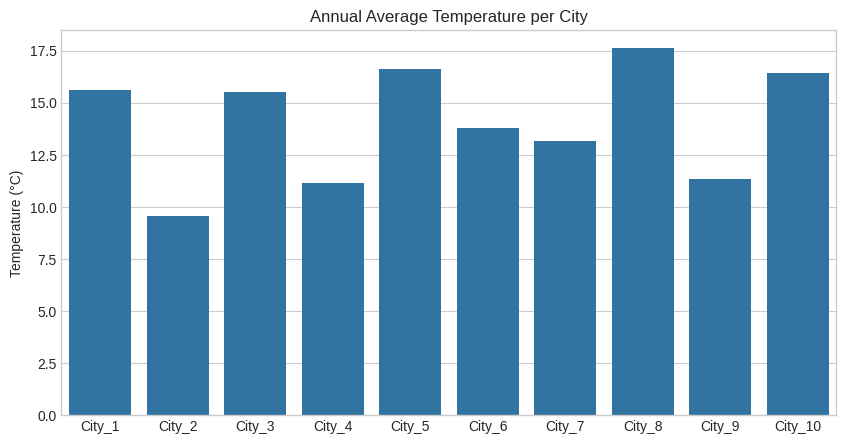

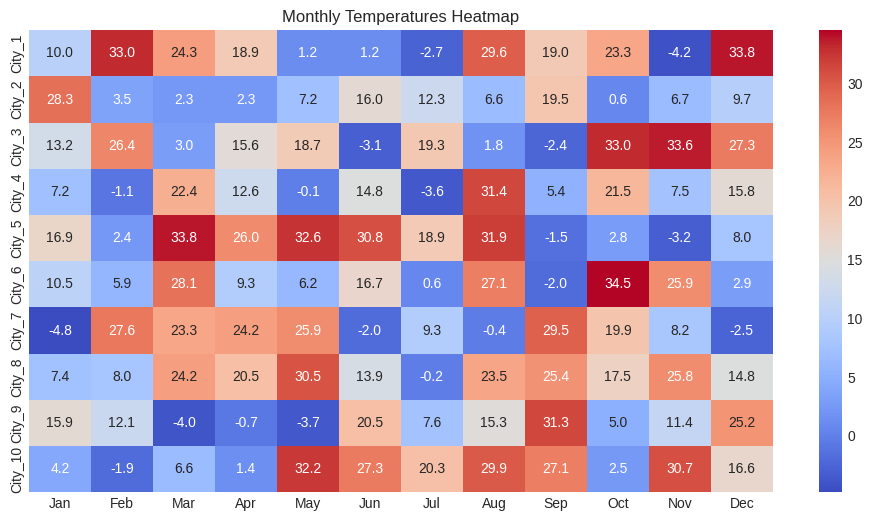

In [70]:
# === LIVE CODING: Create visualization ===
# -----------------------
# STEP 4: Visualize
# -----------------------
plt.figure(figsize=(10,5))
sns.barplot(x=cities, y=annual_avg)
plt.title('Annual Average Temperature per City')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(df[months], annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Monthly Temperatures Heatmap')
plt.show()

## Your Turn: Independent Practice

Now do it yourself! Generate NEW weather data (use a different seed), analyze it, and visualize it.

In [ ]:
# YOUR TURN: Complete weather analysis
# Use a different seed (e.g., np.random.seed(123))

# Step 1: Generate data


# Step 2: Analyze (annual avg, hottest/coldest city)


# Step 3: Convert to DataFrame


# Step 4: Visualize


---

# Wrap Up

---

## Quick Reference - Today's Key Patterns

```python
# CREATING ARRAYS
np.array([1, 2, 3])              # From list
np.arange(start, stop, step)     # Range (like Python range)
np.zeros((rows, cols))           # Filled with 0s
np.ones((rows, cols))            # Filled with 1s
np.eye(n)                        # Identity matrix
np.linspace(start, stop, count)  # Exact count of points

# ATTRIBUTES
arr.shape    # Dimensions
arr.dtype    # Data type
arr.ndim     # Number of dimensions
arr.size     # Total elements

# INDEXING & SLICING
arr[0]            # First element
arr[-1]           # Last element
arr[2:5]          # Slice
arr[::-1]         # Reverse
matrix[row, col]  # 2D access
matrix[1]         # Entire row
matrix[:, 2]      # Entire column

# OPERATIONS
arr + 10          # Add to all
arr * 2           # Multiply all
arr.sum()         # Total
arr.mean()        # Average
arr.min() / .max()        # Value
arr.argmin() / .argmax()  # Position of min/max
matrix.sum(axis=0) # Per column
matrix.sum(axis=1) # Per row

# RESHAPE
arr.reshape(rows, cols)   # Must match total elements

# RANDOM
np.random.seed(42)              # Reproducibility
np.random.random((rows, cols))  # Floats [0, 1)
np.random.uniform(a, b, size)   # Floats [a, b)
np.random.randint(a, b, size)   # Integers [a, b)

# BOOLEAN INDEXING
arr[arr > 5]                    # Elements > 5
arr[(arr > 3) & (arr < 8)]     # AND
arr[(arr < 3) | (arr > 8)]     # OR

# TYPE CONVERSION
arr.astype(int)     # Convert to int
arr.astype(float)   # Convert to float
```